Используются тестовые данные.

Средний балл SAT: 1050.0
Загрязненность левой ветки (SAT > 1000): -0.0000
Загрязненность правой ветки (SAT <= 1000): -0.0000


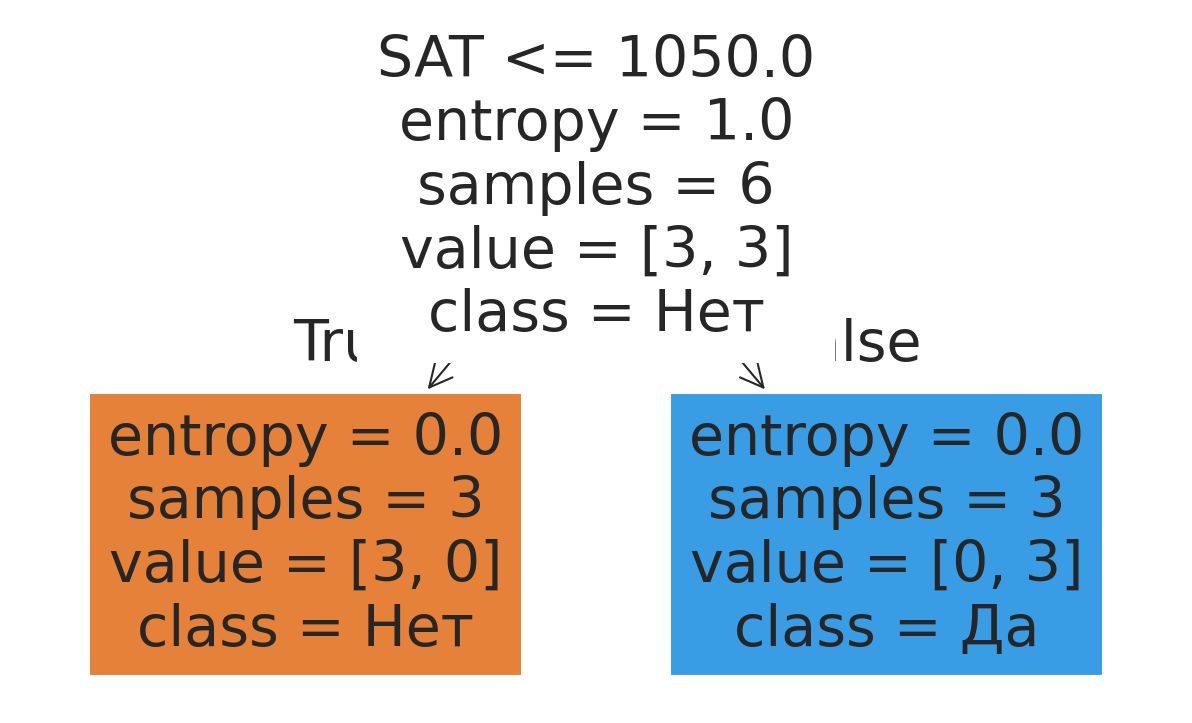

In [5]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. ЗАГРУЗКА ДАННЫХ
try:
    df = pd.read_excel('Файл')
    print("Файл")
except:
    # Если файла под рукой нет, создаем данные  вручную
    data = {
        'IELTS': [9.0, 8.5, 5.5, 5.0, 7.0, 6.5],
        'SAT': [1600, 1200, 700, 700, 1100, 1000],
        'Motivation': [1, 1, 1, 0, 1, 0], # 1 - high, 0 - low
        'Accepted': [1, 1, 0, 0, 1, 0]    # 1 - да, 0 - нет
    }
    df = pd.DataFrame(data)
    print("Используются тестовые данные.")

# 2. РАСЧЕТ СРЕДНЕГО ЗНАЧЕНИЯ
print(f"\nСредний балл SAT: {df['SAT'].mean()}")

# 3. ФУНКЦИЯ ДЛЯ РАСЧЕТА ЗАГРЯЗНЕННОСТИ (Энтропия)
def calculate_entropy(y):
    if len(y) == 0: return 0
    proportions = y.value_counts(normalize=True)
    return -np.sum([p * np.log2(p) for p in proportions if p > 0])

# 4. ЛОГИКА РАЗДЕЛЕНИЯ
threshold = 1000
left_branch = df[df['SAT'] > threshold]
right_branch = df[df['SAT'] <= threshold]

ent_left = calculate_entropy(left_branch['Accepted'])
ent_right = calculate_entropy(right_branch['Accepted'])

print(f"Загрязненность левой ветки (SAT > {threshold}): {ent_left:.4f}")
print(f"Загрязненность правой ветки (SAT <= {threshold}): {ent_right:.4f}")

# 5. ПОСТРОЕНИЕ ДЕРЕВА (Визуализация)
X = df[['IELTS', 'SAT', 'Motivation']]
y = df['Accepted']

clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=X.columns, class_names=['Нет', 'Да'], filled=True)
plt.show()

In [6]:
import pandas as pd

# 1. Создаем DataFrame
df = pd.read_csv('students.csv')

# 2. Расчет среднего значения
# Используем IELTS как пример наиболее информативного признака
value = df['IELTS'].mean()
print(f"Среднее значение (value) для IELTS: {value:.2f}")

# 3. Логика разделения по условию
# Проверяем, кто ВЫШЕ среднего
print("\n--- Если IELTS > value ---")
group_above = df[df['IELTS'] > value]
print(group_above[['IELTS', 'result']])

# Проверяем, кто НИЖЕ среднего
print("\n--- Если IELTS <= value ---")
group_below = df[df['IELTS'] <= value]
print(group_below[['IELTS', 'result']])

# 4. Итоговый вывод информативности (сколько 'yes' и 'no' в каждой группе)
print("\nИнформативность разделения:")
print("Выше среднего (результаты):", group_above['result'].value_counts().to_dict())
print("Ниже среднего (результаты):", group_below['result'].value_counts().to_dict())



import pandas as pd
df = pd.read_csv('students.csv')

# Подготовим список признаков для проверки
features = ['IELTS', 'SAT', 'Motivation']

# Если Motivation еще текстом (high или же low), переведем в числа для расчета среднегоооо
if df['Motivation'].dtype == 'object':
    df['Motivation_val'] = df['Motivation'].map({'high': 1, 'low': 0})
    features[2] = 'Motivation_val'

for col in features:
    print(f"\n{'='*10} АНАЛИЗ ПРИЗНАКА: {col} {'='*10}")

    # Считаем среднее (value)
    value = df[col].mean()
    print(f"Среднее значение (порог): {value:.2f}")

    # Разделяем на группы
    above = df[df[col] > value]
    below = df[df[col] <= value]

    # Выводим результат информативности
    print(f"Выше среднего (результаты): {above['result'].value_counts().to_dict()}")
    print(f"Ниже среднего (результаты): {below['result'].value_counts().to_dict()}")

    # Короткий вывод тоже
    if len(above['result'].unique()) == 1 and len(below['result'].unique()) == 1:
        print(f"Результат: Признак {col} ИДЕАЛЬНО разделяет данные.")
    else:
        print(f"Результат: Признак {col} дает смешанные результаты.")

Среднее значение (value) для IELTS: 6.92

--- Если IELTS > value ---
   IELTS result
0    9.0    yes
1    8.5    yes
4    7.0    yes

--- Если IELTS <= value ---
   IELTS result
2    5.5     no
3    5.0     no
5    6.5     no

Информативность разделения:
Выше среднего (результаты): {'yes': 3}
Ниже среднего (результаты): {'no': 3}

========== АНАЛИЗ ПРИЗНАКА: IELTS ==========
Среднее значение (порог): 6.92
Выше среднего (результаты): {'yes': 3}
Ниже среднего (результаты): {'no': 3}
Результат: Признак IELTS ИДЕАЛЬНО разделяет данные.

========== АНАЛИЗ ПРИЗНАКА: SAT ==========
Среднее значение (порог): 1050.00
Выше среднего (результаты): {'yes': 3}
Ниже среднего (результаты): {'no': 3}
Результат: Признак SAT ИДЕАЛЬНО разделяет данные.

========== АНАЛИЗ ПРИЗНАКА: Motivation_val ==========
Среднее значение (порог): 0.67
Выше среднего (результаты): {'yes': 3, 'no': 1}
Ниже среднего (результаты): {'no': 2}
Результат: Признак Motivation_val дает смешанные результаты.


✅ Данные считаны!


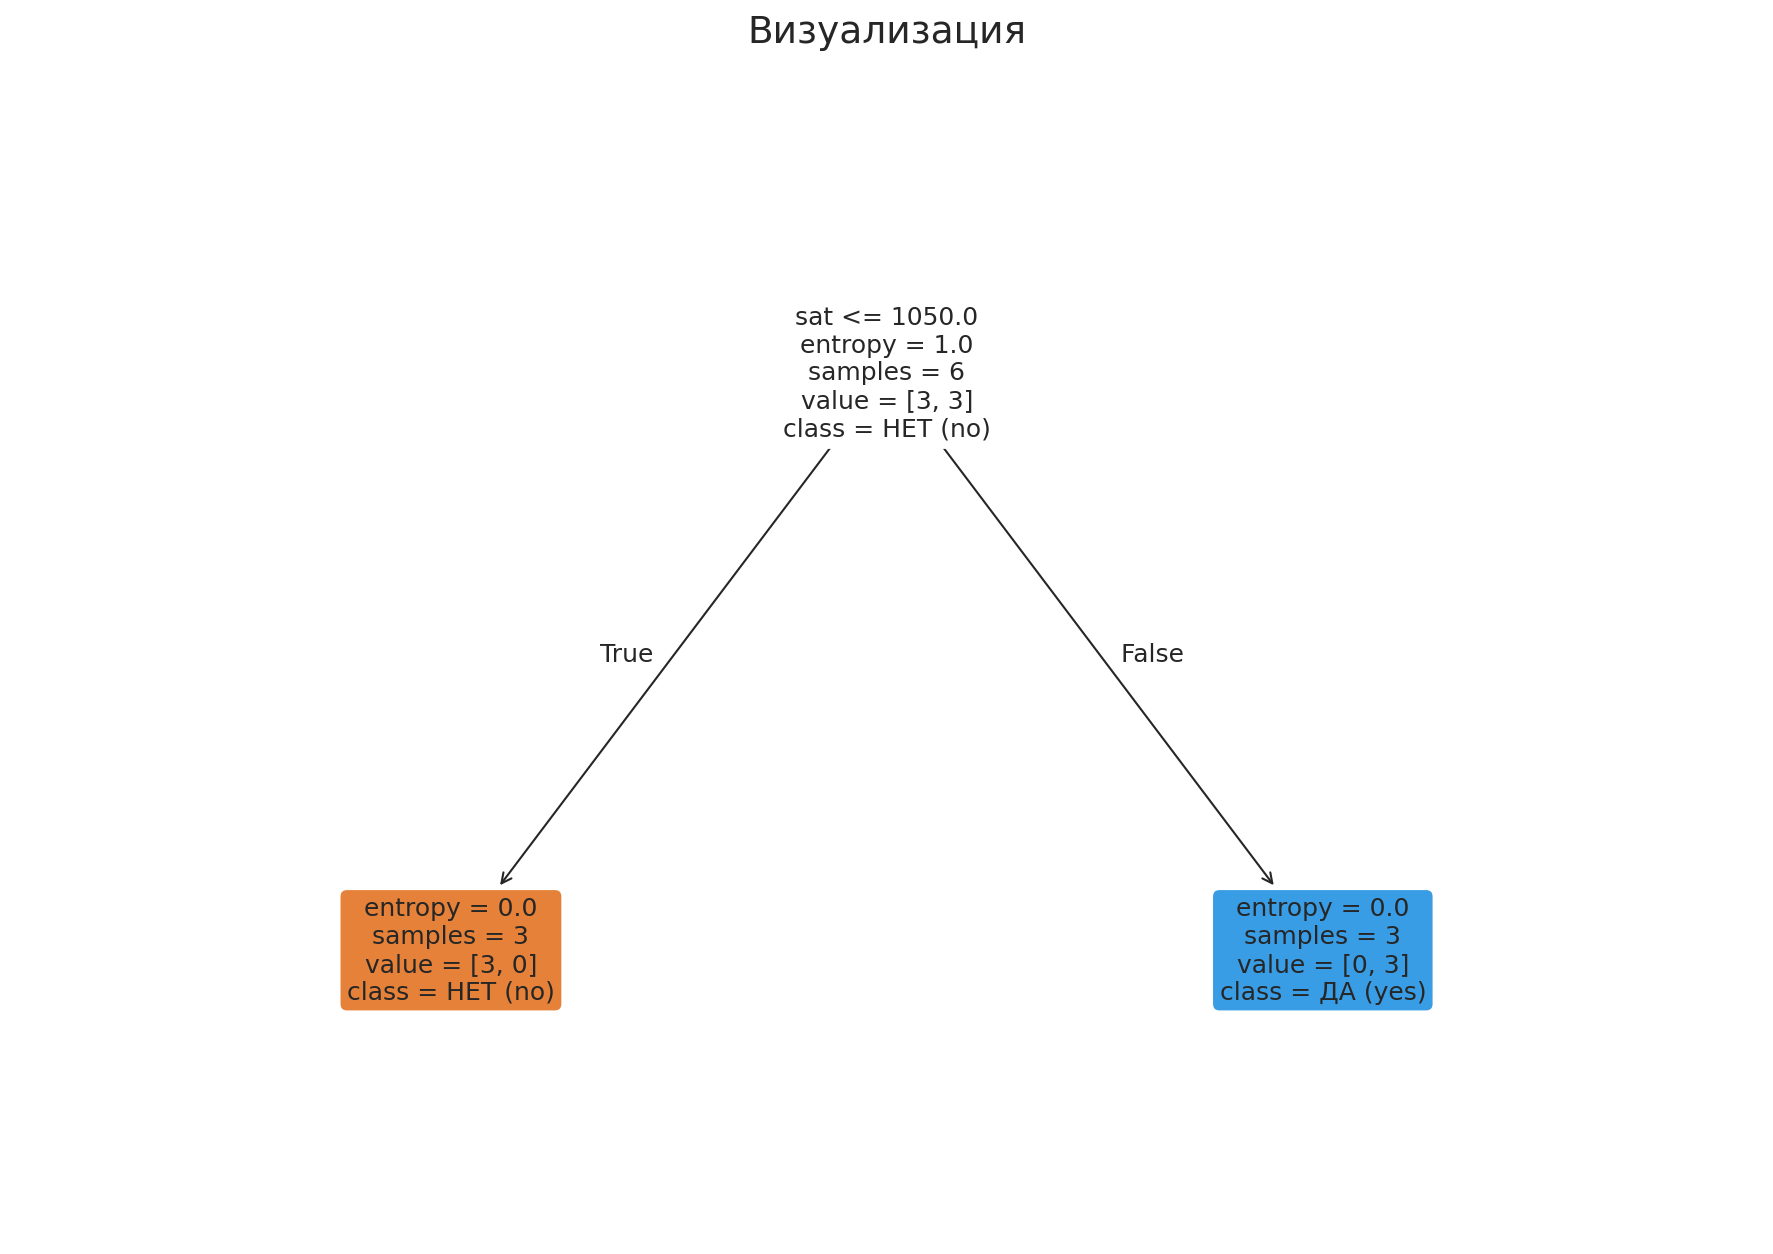

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Загрузка и подготовка
try:
    df = pd.read_csv('students.csv')
    # Приводим названия к нижнему регистру, чтобы не было ошибок
    df.columns = df.columns.str.strip().str.lower()
    print("✅ Данные считаны!")
except:
    print("❌ Файл не найден, проверьте загрузку students.csv")

# 2. Обработка данных
df_num = df.copy()
if 'motivation' in df_num.columns:
    df_num['motivation'] = df_num['motivation'].map({'high': 1, 'low': 0})
if 'result' in df_num.columns:
    df_num['result'] = df_num['result'].map({'yes': 1, 'no': 0})

# 3. Обучение модели
features = ['ielts', 'sat', 'motivation']
X = df_num[features]
y = df_num['result']

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf.fit(X, y)

# 4. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(15, 10), facecolor='white')

# Сама отрисовка
plot_tree(clf,
          feature_names=features,
          class_names=['НЕТ (no)', 'ДА (yes)'],
          filled=True,      # Заливка цветом
          rounded=True,     # Скругленные углы
          fontsize=12,      # Читаемый шрифт
          precision=2)      # Округление до 2 знаков

plt.title("Визуализация", fontsize=18, pad=20)
plt.show()